# Taller 4 — Transformaciones Básicas 
**Herramientas:** `numpy`, `matplotlib`, `imageio`

Se aplican traslación, rotación y escala usando matrices de transformación homogéneas sobre una figura 2D, y se exporta una animación como GIF.

In [9]:
# Se importan las librerías necesarias para el procesamiento de imágenes, la visualización y la manipulación de archivos.

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
from IPython.display import Image


## 1. Figura 2D

Usamos un polígono en forma de flecha/casa para que las transformaciones sean fáciles de visualizar.

In [2]:
figura_base = np.array([
    [-1, -1],
    [ 1, -1],
    [ 1,  0],
    [ 0,  1],
    [-1,  0],
    [-1, -1],
], dtype=float).T  # shape (2, N)

## 2. Matrices de transformación homogéneas

In [3]:
def mat_traslacion(tx, ty):
    return np.array([[1,0,tx],[0,1,ty],[0,0,1]])

def mat_rotacion(angulo):
    c, s = np.cos(angulo), np.sin(angulo)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def mat_escala(sx, sy):
    return np.array([[sx,0,0],[0,sy,0],[0,0,1]])

def aplicar(matriz, puntos):
    homo = np.vstack([puntos, np.ones((1, puntos.shape[1]))])
    return (matriz @ homo)[:2]

## 3. Animación en función del tiempo → GIF
Primero se define la funcion para dibujar en un plano la figura 2D y su transformación respectiva, si no corresponde, se dibuja originalmente

In [4]:
def dibujar(ax, puntos, color, titulo, matriz_txt=None):
    ax.fill(puntos[0], puntos[1], alpha=0.6, color=color)
    ax.plot(puntos[0], puntos[1], color='black', linewidth=1.2)
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    if matriz_txt:
        ax.text(-5.5, -5.5, matriz_txt, fontsize=7, family='monospace',
                verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

Cada frame corresponde a un valor de `t ∈ [0,1)`. Las transformaciones varían con `t`, para referirse al tiempo:
- **Traslación:** oscila en X con `sin(2πt)`
- **Rotación:** gira 360° completo
- **Escala:** oscila entre 0.5x y 1.5x
- **Combinada:** aplica S → R → T encadenadas

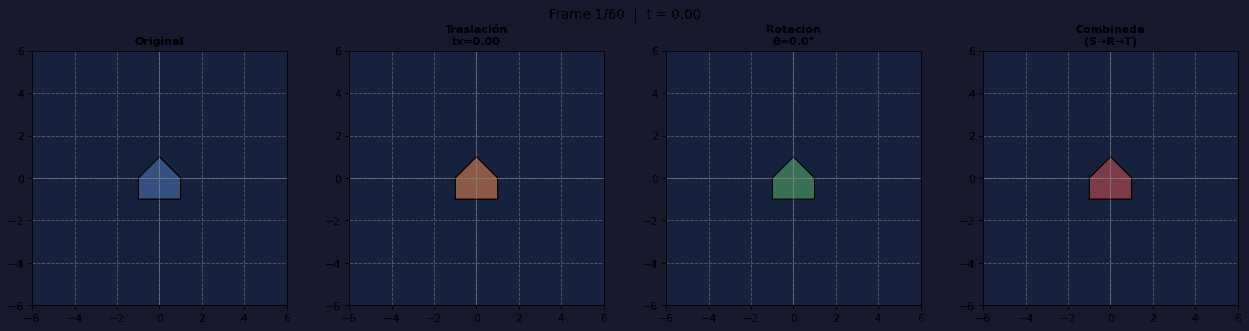

In [ ]:
frames = []
n_frames = 60
os.makedirs('frames', exist_ok=True)

for i in range(n_frames):
    t = i / n_frames
    angulo = 2 * np.pi * t

    T_anim = mat_traslacion(3 * np.sin(2 * np.pi * t), 0)
    R_anim = mat_rotacion(angulo)
    S_anim = mat_escala(1 + 0.5 * np.sin(2 * np.pi * t), 1 + 0.5 * np.sin(2 * np.pi * t))
    M_combinada = T_anim @ R_anim @ S_anim

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Frame {i+1}/{n_frames}  |  t = {t:.2f}', fontsize=12)
    fig.patch.set_facecolor('#1a1a2e')
    for ax in axes:
        ax.set_facecolor('#16213e')

    dibujar(axes[0], figura_base, '#4C72B0', 'Original')
    dibujar(axes[1], aplicar(T_anim,      figura_base),   '#DD8452', f'Traslación\ntx={3*np.sin(2*np.pi*t):.2f}')
    dibujar(axes[2], aplicar(R_anim,      figura_base),   '#55A868', f'Rotación\nθ={np.degrees(angulo):.1f}°')
    dibujar(axes[3], aplicar(M_combinada, figura_base),   '#C44E52', 'Combinada\n(S→R→T)')

    plt.tight_layout()
    
    fname = f'frames/frame_{i:03d}.png'
    plt.savefig(fname, dpi=80, bbox_inches='tight')
    plt.close()
    frames.append(fname)

with imageio.get_writer('../media/python_transformaciones.gif', mode='I', duration=1/24, loop=0) as writer:
    for fname in frames:
        writer.append_data(imageio.imread(fname))

Image('../media/python_transformaciones.gif')


## 4. Comparativa de transformaciones en el tiempo -> BONUS


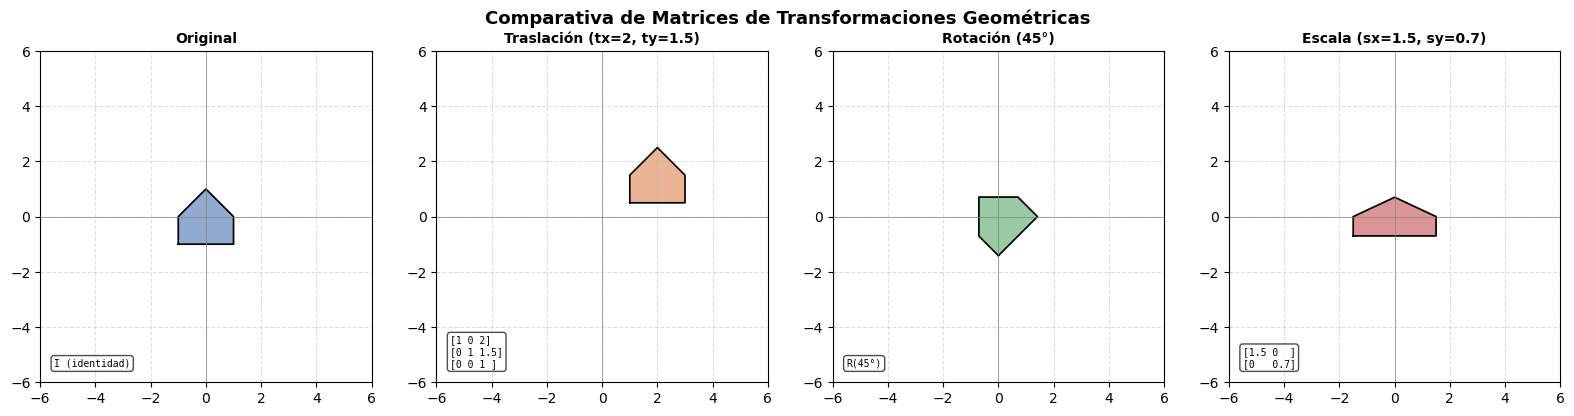

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Comparativa de Matrices de Transformaciones Geométricas', fontsize=13, fontweight='bold')

dibujar(axes[0], figura_base, '#4C72B0', 'Original', 'I (identidad)')
dibujar(axes[1], aplicar(mat_traslacion(2,1.5), figura_base), '#DD8452', 'Traslación (tx=2, ty=1.5)', '[1 0 2]\n[0 1 1.5]\n[0 0 1 ]')
dibujar(axes[2], aplicar(mat_rotacion(np.pi/4), figura_base), '#55A868', 'Rotación (45°)',            'R(45°)')
dibujar(axes[3], aplicar(mat_escala(1.5, 0.7),  figura_base), '#C44E52', 'Escala (sx=1.5, sy=0.7)', '[1.5 0  ]\n[0   0.7]')

plt.tight_layout()
plt.savefig('../media/python_bonus.png', dpi=120, bbox_inches='tight')
plt.show()